### To make a complete system, first we make them in ipynb and later make corresponding python .py files for each

#### AI Tutor is a multi-agent agentic system that follows multi-agent architecture.

##### We add multiple specialized agents to the AI Tutor that works autonomouly parallely or sequentially based upon the requirements to reach/achieve the goal. Supervisor being at the top makes the goal into sub-goals and provide the sub-goal to corresponding agents based upon the specialization

##### All the necessary imports are:

In [92]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Literal, TypedDict, Optional, List, Annotated
import operator
from langchain_ollama import OllamaEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage, BaseMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from langgraph_supervisor import create_supervisor
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages
from langgraph.types import Command, Interrupt
from dotenv import load_dotenv
import os

In [93]:
load_dotenv()

True

#### Supervisor and Workers:- 
##### We need to make a supervisor agent where all the workers agent that are going to work and their use are given to the supervisor using prompt so that it can make reasoning and then handsoff the corresponding agent.

### tools

In [71]:
llm = ChatGroq(
    api_key=os.getenv("api_key"),
    model = os.getenv("model")
)

tavily_research_tool = TavilySearch(max_results=3, include_answer= True, search_depth= "advanced", auto_parameters=True)
tavily_research_tool.invoke({"query" : "who is ronaldo"})

{'query': 'who is ronaldo',
 'follow_up_questions': None,
 'answer': "Cristiano Ronaldo, born on February 5, 1985, is a Portuguese soccer superstar known for his prolific goal-scoring and five Ballon d'Or awards. He played for Manchester United, Real Madrid, Juventus, and currently Al-Nassr FC. Ronaldo is the first soccer player to become a billionaire.",
 'images': [],
 'results': [{'url': 'https://www.biography.com/athletes/cristiano-ronaldo',
   'title': 'Cristiano Ronaldo: Biography, Soccer Player, Al-Nassr Star',
   'content': '## Jump to:\n\n## Who Is Cristiano Ronaldo?\n\nPortuguese soccer superstar Cristiano Ronaldo is one of the greatest athletes in the sport’s history, winning the Ballon d’Or five times and becoming the first player to score 900 career goals. Considered a phenom as a teenager, 16-year-old Ronaldo signed with Manchester United in a record deal for a player of his age. He set a franchise record for goals scored in 2008, before transferring to Real Madrid the fo

In [72]:
tools = [tavily_research_tool]

tools_by_name = {tool.name : tool for tool in tools}
print(tools_by_name)
llm_with_tools = llm.bind_tools([tavily_research_tool])

res = llm_with_tools.invoke([SystemMessage(content="think that you are an AI research agent and you have to make a decision to use the llm itself for answering or usng the correct tool among the available tools with all the approproate args required to it") ,"Who is the current pm of nepal?"])

print(f"Content:- {res.content}\n{'*'*140}\nReasoning:- {res.additional_kwargs['reasoning_content']}\n{'*'*140}\nTool Calls:- {res.tool_calls}\n{'*'*140}\n")

if res.content == "":
    res = tools_by_name[res.tool_calls[0]['name']].invoke(res.tool_calls[0])
    print(res)

{'tavily_search': TavilySearch(auto_parameters=True, search_depth='advanced', max_results=3, include_answer=True, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))}
Content:- 
********************************************************************************************************************************************
Reasoning:- The user asks: "Who is the current pm of nepal?" Need up-to-date info. It's a current event question. Use tavily_search to get latest info. Provide answer with citation. So we need to call search.
********************************************************************************************************************************************
Tool Calls:- [{'name': 'tavily_search', 'args': {'query': 'current prime minister of Nepal', 'search_depth': 'fast', 'time_range': 'year'}, 'id': 'fc_f3e8a3eb-fb96-47d6-8964-e7ac6488c0a4', 'type': 'tool_call'}]
*****************************************************************************

In [90]:
# making dictionary for each of the agents tool

# research agent
research_tools = [tavily_research_tool]
research_tools_by_name = {tool.name : tool for tool in research_tools}

# task_specific_agent
task_specific_tools = []
task_specific_tools_by_name = {tool.name : tool for tool in task_specific_tools}

# scrapping_agent
scrapping_tools = []
scrapping_tools_by_name = {tool.name : tool for tool in scrapping_tools}

#rag_agent
rag_tools = []
rag_tools_by_name = {tool.name : tool for tool in rag_tools}

# youtube_agent
youtube_tools = []
youtube_tools_by_name = {tool.name : tool for tool in youtube_tools}

### LLM for each agents with tools binded to it

In [99]:
llm = ChatGroq(model= os.getenv("model"), api_key=os.getenv("api_key"))
research_agent_with_tool =  llm.bind_tools(research_tools)
rag_agent_with_tool = llm.bind_tools(rag_tools)
youtube_agent_with_tool = llm.bind_tools(youtube_tools)
task_agent_with_tool = llm.bind_tools(youtube_tools)


In [74]:
class State(TypedDict):
    pass

class SubState(TypedDict):
    pass

In [75]:
# FOR THE SUPERVISOR NODE
def Supervisor(state : State):
    pass

In [76]:
# FOR THE RESEARCH NODE
def Researcher(state : State):
    pass

In [77]:
# FOR THE SCRAPPER NODE
def Scrapper(state : State):
    pass

In [78]:
def YoutubeVideos(state : State):
    pass

In [79]:
# FOR THE YOUTUBEVIDEOS NODE
def TaskSpecific(state : State):
    # We make subgraph as it will contain multiple agents in side the TaskSpecific agent:
    # Sub-Supervisor
    # Worker Agents:
        # Q/A and FlashCards
        # StudyPlanner
    # All agents will have same tool as not needed much
    pass

In [80]:
# FOR THE RAG AGENT
def RAG(state : State):
    # this is a subgraph that contains a whole research-based, retriever, purifier, synthesizer
    pass

In [81]:
# at the end when all the task are completed then all the results from each agent are synthesized into proper format
def Synthesizer(state : State):
    # At last synthesize the whole blog/goal that are broken down and submitted to all the agents into one single organized form
    pass

In [82]:
def AgentSelection(state : State):
    if 1:
        return "Researcher"
    elif 2: 
        return "RAG"
    elif 3:
        return "Scrapper"
    elif 4:
        return "TaskSpecific"
    else:
        return "END"

In [83]:
def MiniSuervisor(state : SubState):
    pass

def StudyPlanner(state : SubState):
    pass

def QAandFlashCards(state : SubState):
    pass

def SubAgentSelection(state : SubState):
    if 1:
        return "QAandFlashCards"
    
    elif 2:
        return "StudyPlanner"
    
    elif 3:
        return "END"

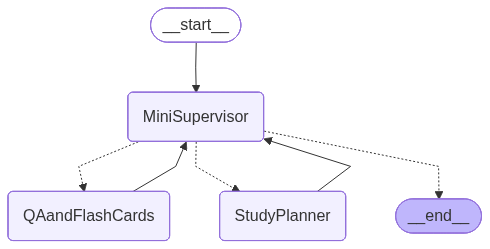

In [84]:
subGraph = StateGraph(State)
subGraph.add_node("MiniSupervisor", MiniSuervisor)
subGraph.add_node("StudyPlanner", StudyPlanner)
subGraph.add_node("QAandFlashCards", QAandFlashCards)

subGraph.add_edge(START, "MiniSupervisor")
subGraph.add_conditional_edges("MiniSupervisor", SubAgentSelection,{"QAandFlashCards" : "QAandFlashCards", "StudyPlanner" : "StudyPlanner"})
subGraph.add_edge("QAandFlashCards", "MiniSupervisor")
subGraph.add_edge("StudyPlanner", "MiniSupervisor")
subGraph.add_edge("MiniSupervisor", END)

subSystem = subGraph.compile()

subSystem

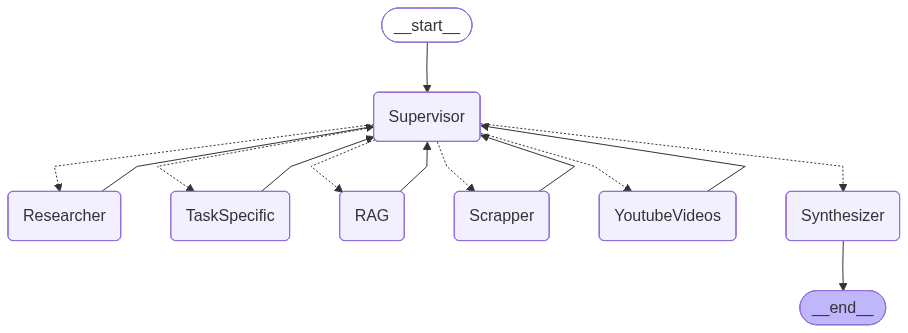

In [85]:
graph = StateGraph(State)
graph.add_node("Supervisor", Supervisor)
graph.add_node("Researcher", Researcher)
graph.add_node("TaskSpecific", TaskSpecific)    
graph.add_node("RAG", RAG)
graph.add_node("Scrapper", Scrapper)
graph.add_node("YoutubeVideos", YoutubeVideos)
graph.add_node("Synthesizer", Synthesizer)

graph.add_edge(START, "Supervisor")
graph.add_conditional_edges("Supervisor", AgentSelection, {"Researcher" : "Researcher", "RAG" : "RAG", "Scrapper" : "Scrapper", "YoutubeVideos" : "YoutubeVideos", "TaskSpecific" : "TaskSpecific", "Synthesizer" : "Synthesizer"})
graph.add_edge("Researcher", "Supervisor")
graph.add_edge("RAG", "Supervisor")
graph.add_edge("Scrapper", "Supervisor")
graph.add_edge("TaskSpecific", "Supervisor")
graph.add_edge("YoutubeVideos", "Supervisor")
graph.add_edge("Synthesizer", END)

system = graph.compile()

system

